# 原始数据处理

In [7]:
import pandas as pd
import glob
import os

from fontTools.misc.cython import returns

# 你的Excel文件夹
folder = r'U:\YuanqiHua\High speed\Final analysis\First10hb\test'

# 找到所有xlsx文件
files = [f for f in glob.glob(folder + r'\*.csv') if 'combined' not in f]

all_df = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # ⭐ 添加 Filename 列（只保留文件名，不含路径）
    filename = os.path.basename(file)
    df["Filename"] = filename

    all_df.append(df)

# 纵向拼接（append）
final_df = pd.concat(all_df, ignore_index=True)

# 保存
final_df.to_csv(folder + r'\combined.csv', index=False)

print("All files combined.")


Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260114  wt1 MTZ control_1000fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260122 wt1 MTZ_1000fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260123 wt1 MTZ_1000fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260127 dmrt3 MTZ_1000fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260128 dmrt3 MTZ(1000hz)_1000fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260128 dmrt3 MTZ(800hz)_800fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260129 wt1 MTZ(800hz)_800fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260204 wt1 MTZ(750hz)_750fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260205 wt1 MTZ_750fps_HB10.csv
Processing: U:\YuanqiHua\High speed\Final analysis\First10hb\test\260212 MTZ c

In [3]:
infile = r"U:\YuanqiHua\High speed\Final analysis\First10hb\test\combined.csv"   # 你本地就换成 r"U:\...\combined.csv"
df = pd.read_csv(infile)

# 读取

In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
import  tempfile
import matplotlib.colors as mcolors
import pandas as pd
import glob
import os
from plot import (
    freq_dist_all,
    freq_dist_all2,
    freq_dist_single,
    head_tail,
    within_group,
    holm_correction,
    darken,
    star,
    add_sig,
)
from Process import (
    rm_outliers,
    make_clean_dfs
)

In [2]:
# =========================
# 1) 读入数据
# =========================
folder = r'U:\YuanqiHua\High speed\Final analysis\test'

infile = r"U:\YuanqiHua\High speed\Final analysis\test\combined.csv"   # 你本地就换成 r"U:\...\combined.csv"
df = pd.read_csv(infile)


In [6]:
infile2 = r"U:\YuanqiHua\High speed\Final analysis\First10hb\test\combined.csv"   # 你本地就换成 r"U:\...\combined.csv"
df2 = pd.read_csv(infile2)

FileNotFoundError: [Errno 2] No such file or directory: 'U:\\YuanqiHua\\High speed\\Final analysis\\First10hb\\test\\combined.csv'

In [5]:
# =========================
# 2) 生成 Stimulus / Group
#    规则：
#    - 有 HS => Head stimulus，否则 Tail stimulus
#    - 含 control 或 ctrl => Control
#    - 否则：含 wt1 => wt1_MTZ；含 d3 => d3_MTZ
# =========================

# 统一小写方便判断
geno = df["Genotype"].astype(str).str.lower()

# Stimulus
df["Stimulus"] = geno.fillna("").str.lower().apply(lambda x:
                                                    "Head" if "hs" in x
                                                    else "OMR" if ("omr" in x or "fs" in x)
                                                    else "Tail"
                                                   )

# Group
def get_group(x):
    if "control" in x or "ctrl" in x:
        return "Control"
    elif "wt1" in x:
        return "wt1_MTZ"
    elif "d3" in x:
        return "d3_MTZ"

df["Group"] = geno.apply(get_group)
print(df["Stimulus"])

0      Tail
1      Tail
2      Tail
3      Tail
4      Tail
       ... 
908     OMR
909     OMR
910     OMR
911     OMR
912     OMR
Name: Stimulus, Length: 913, dtype: object


In [6]:
# unique ID
df["fish_key"] = df["Filename"].astype(str) + "_" + df["Larva ID"].astype(str)
df["UniqueID"] = df.groupby("Group")["fish_key"].transform(lambda s: pd.factorize(s)[0] + 1)


In [7]:
df.to_csv(folder + r'\combined.csv', index=False)


## QC （剔除单侧摆动的情况）

In [5]:
df[df["Nr. half beats"] < 2]

,Larva ID,Genotype,Swim_ID,Peak_sequence,Peak_deflection,Movement duration,Nr. half beats,Freq. half beats,Alternation,Max. deflection,...,Mean curvature during swimming beats,Turning bias to R/L during swimming,Laterality_Index_swimming,Swimming_valid,Fail_reason,Filename,Stimulus,Group,fish_key,UniqueID
41,2,wt1-MTZ,7,R,15.929,0.031,1,32.258,NaN,15.929,...,74.614,inf,1.0,1,NaN,260122 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260122 wt1 MTZ_1000fps.csv_2,2
46,3,wt1-MTZ,4,R,64.144,0.017,1,58.824,NaN,64.144,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260122 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260122 wt1 MTZ_1000fps.csv_3,3
89,3,wt1-MTZ,7,R,41.315,0.073,1,13.699,NaN,41.315,...,81.982,inf,1.0,1,NaN,260123 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260123 wt1 MTZ_1000fps.csv_3,7
96,4,wt1-MTZ,6,R,28.381,0.056,1,17.857,NaN,28.381,...,45.968,inf,1.0,1,NaN,260123 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260123 wt1 MTZ_1000fps.csv_4,8
98,5,wt1-MTZ,2,L,-50.964,0.042,1,23.810,NaN,50.964,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260123 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260123 wt1 MTZ_1000fps.csv_5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,1,d3-MTZ-FS,7,L,-8.847,0.029,1,34.483,NaN,8.847,...,106.997,0.0,-1.0,1,NaN,260225 dmrt3 MTZ_750fps.csv,OMR,d3_MTZ,260225 dmrt3 MTZ_750fps.csv_1,19
596,1,d3-MTZ-OMR,0,L,-77.219,0.043,1,23.256,NaN,77.219,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260225 dmrt3 MTZ_750fps.csv,OMR,d3_MTZ,260225 dmrt3 MTZ_750fps.csv_1,19
612,1,MTZ-ctrl-HS,1,R,60.717,0.028,1,35.714,NaN,60.717,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260226 MTZ control_750fps.csv,Head,Control,260226 MTZ control_750fps.csv_1,18
614,1,MTZ-ctrl-HS,3,R,61.959,0.049,1,20.408,NaN,61.959,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260226 MTZ control_750fps.csv,Head,Control,260226 MTZ control_750fps.csv_1,18


In [6]:
summary = (
    df
    .assign(HB_less2 = df["Nr. half beats"] < 2)
    .groupby("Group")
    .agg(
        total_counts = ("Nr. half beats", "count"),
        less2_count = ("HB_less2", "sum")
    )
)

print(summary)

# df["Nr. half beats"] < 2 得到布尔序列
# .assign(HB_less2 = df["Nr. half beats"] < 2) 原来的 df上新增一列 HB_less2

         total_counts  less2_count
Group                             
Control           322           16
d3_MTZ            355           16
wt1_MTZ           236           34


In [21]:
print(df.loc[df["Nr. half beats"] < 2,
       ["Filename","Larva ID","Swim_ID","Stimulus","Nr. half beats","Alternation","Group"]].sort_values(by="Filename")
      )

# df.loc[行条件, 列选择] 选出 Nr. half beats 小于 2 的所有行，只保留后面列出来的这几列。

                           Filename  Larva ID  Swim_ID Stimulus  \
19   260114 MTZ control_1000fps.csv         2        2     Tail   
50       260122 wt1 MTZ_1000fps.csv         3        4     Tail   
202     260128 dmrt3 MTZ_800fps.csv         3        3     Tail   
203     260128 dmrt3 MTZ_800fps.csv         3        4     Tail   
289       260204 wt1 MTZ_750fps.csv         2        3     Tail   
312       260204 wt1 MTZ_750fps.csv         2       11     Head   
313       260204 wt1 MTZ_750fps.csv         2       12     Head   
322       260204 wt1 MTZ_750fps.csv         2        9     Head   
373       260205 wt1 MTZ_750fps.csv         4        3     Head   
370       260205 wt1 MTZ_750fps.csv         4        0     Head   
342       260205 wt1 MTZ_750fps.csv         4        5     Tail   
357       260205 wt1 MTZ_750fps.csv         1        5     Head   
455   260212 MTZ control_750fps.csv         3        2     Head   
456   260212 MTZ control_750fps.csv         3        3     Hea

In [3]:
# 剔除单侧摆动的情况
df_original = df.copy()
df = df[df["Nr. half beats"] >= 2].copy()

### First10Hb 清洗

In [136]:
counts = (
    df.groupby(['Group','UniqueID','Swim_ID'])
      .size()
      .reset_index(name='count')
)

counts[counts['count'] <= 2]

,Group,UniqueID,Swim_ID,count
2,Control,1,2,2
46,Control,5,7,1
75,Control,8,0,2
77,Control,8,2,2
79,Control,8,4,2
...,...,...,...,...
567,wt1_MTZ,22,3,2
568,wt1_MTZ,22,4,2
571,wt1_MTZ,23,2,1
573,wt1_MTZ,24,0,2


In [140]:
mask = df.groupby(['Group','UniqueID','Swim_ID'])['Swim_ID'].transform('size') <= 2
df_small = df[mask]
print(df_small)

      Larva ID         Genotype  Swim_ID  HB_index  Interval_s  Inst_freq_Hz  \
94           1  wt1-MTZ-control        2         1    0.086000     11.627907   
95           1  wt1-MTZ-control        2         2    0.069000     14.492754   
303          1          wt1-MTZ        1         1    0.033000     30.303030   
304          2          wt1-MTZ        0         1    0.056000     17.857143   
313          3          wt1-MTZ        2         1    0.042000     23.809524   
...        ...              ...      ...       ...         ...           ...   
2653         4     MTZ-ctrl-OMR       15         2    0.026667     37.500000   
2729         4     MTZ-ctrl-OMR        7         1    0.026667     37.500000   
2730         4     MTZ-ctrl-OMR        7         2    0.028000     35.714286   
2735         4     MTZ-ctrl-OMR        9         1    0.025333     39.473684   
2736         4     MTZ-ctrl-OMR        9         2    0.026667     37.500000   

                                       

In [141]:
mask = df.groupby(['Group','UniqueID','Swim_ID'])['Swim_ID'].transform('size') > 2
df_filter = df[mask]

In [142]:
df_filter.groupby(['Group','UniqueID','Swim_ID']).size().min()


np.int64(3)

In [143]:
df_filter.to_csv(folder + r'\combined_10Hb_filter.csv', index=False)

## 简单查看

In [8]:
df.groupby(['Stimulus','Group'])['HB10s_alt'].agg(['min', 'max'])


min  max
Stimulus Group                 
Head     Control  0.333333  1.0
         d3_MTZ   0.000000  1.0
         wt1_MTZ  0.500000  1.0
OMR      Control  0.777778  1.0
         d3_MTZ   0.750000  1.0
         wt1_MTZ  0.888889  1.0
Tail     Control  0.000000  1.0
         d3_MTZ   0.500000  1.0
         wt1_MTZ  0.000000  1.0

In [23]:
df.groupby(["Stimulus","Group" ])[["Nr. half beats","Freq. half beats",'Max. deflection','Longest tail trajectory among half beats','Cumulative tail trajectory','Max. curvature','Movement duration','Swimming duration','Turning bias to R/L']].mean()


Nr. half beats  Freq. half beats  Max. deflection  \
Stimulus Group                                                        
Head     Control       11.000000         43.947406        76.084101   
         d3_MTZ         6.732558         31.516640        37.668547   
         wt1_MTZ        6.114286         30.308143        68.613143   
Tail     Control       10.427350         40.972828        66.376274   
         d3_MTZ         7.494505         32.367648        50.448484   
         wt1_MTZ        9.265823         32.645051        58.839367   

                  Longest tail trajectory among half beats  \
Stimulus Group                                               
Head     Control                                424.883377   
         d3_MTZ                                 396.692535   
         wt1_MTZ                                448.066629   
Tail     Control                                633.267948   
         d3_MTZ                                 535.467714   
         wt1_MTZ                                432.960494   

                  Cumulative tail trajectory  Max. curvature  \
Stimulus Group                                                 
Head     Control                 2611.204188      196.947855   
         d3_MTZ                  1344.445209      141.388849   
         wt1_MTZ                 1023.023400      238.171829   
Tail     Control                 4016.901915      187.335479   
         d3_MTZ                  1821.965319      149.823110   
         wt1_MTZ                 1668.716032      210.407152   

                  Movement duration  Swimming duration  Turning bias to R/L  
Stimulus Group                                                               
Head     Control           0.240246           0.254492                  inf  
         d3_MTZ            0.225744           0.218023                  inf  
         wt1_MTZ           0.265514           0.269167                  inf  
Tail     Control           0.257000           0.234060                  inf  
         d3_MTZ            0.226198           0.220885                  inf  
         wt1_MTZ           0.303209           0.293745                  inf

In [24]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('Q("Max. deflection") ~ C(Group) * C(Stimulus)', data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)
print(anova)

# F ：组间差异相对于组内波动的比例,F=组间方差/组内方差。 如果：组之间差异很大, 组内数据很稳定, 那么 F 会很大。
# PR(>F) ：p 值（显著性概率）
# F 大 + p 小 → 真差异
# F 大 + p 大 → 样本不足
# F 小 + p 小 → 样本巨大

# C(Group): 如果把 Head 和 Tail 混在一起看，Control、wt1_MTZ、d3_MTZ 整体水平比较。
# C(Stimulus) : Head vs Tail 在“所有组混在一起”时，平均水平是否不同。
# C(Group):C(Stimulus) ： 不同组对 Head 和 Tail 的反应方式比较。

ModuleNotFoundError: No module named 'statsmodels'

In [12]:
df.groupby(['Group','Stimulus'])['UniqueID'].nunique() # “number of unique values”（唯一值的数量）


Group    Stimulus
Control  Head        11
         OMR          9
         Tail        12
d3_MTZ   Head         7
         OMR         15
         Tail        10
wt1_MTZ  Head         7
         OMR          7
         Tail        23
Name: UniqueID, dtype: int64

# 清洗数据

## Functions

In [12]:
# 测试清洗
ycol = "Freq. half beats"

df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

In [14]:
print("原始 swim 行数:", len(df))
print("清洗后 swim 行数:", len(df_swim_clean))

print("fish 均值行数（清洗后 swim 计算）:", len(df_fish_clean0))
print("fish 再清洗后行数:", len(df_fish_clean))

原始 swim 行数: 847


NameError: name 'df_swim_clean' is not defined

In [15]:
check = (
    df.groupby(["Stimulus","Group"])[ycol].count().rename("raw_swim")
    .to_frame()
    .join(df_swim_clean.groupby(["Stimulus","Group"])[ycol].count().rename("clean_swim"))
    .join(df_fish_clean0.groupby(["Stimulus","Group"])[ycol].count().rename("fish_before_IQR"))
    .join(df_fish_clean.groupby(["Stimulus","Group"])[ycol].count().rename("fish_after_IQR"))
)
print(check)

                  raw_swim  clean_swim  fish_before_IQR  fish_after_IQR
Stimulus Group                                                         
Head     Control        82          80               11              11
         d3_MTZ         87          84                7               7
         wt1_MTZ        28          27                7               6
OMR      Control       114         114                9               9
         d3_MTZ        172         171               15              14
         wt1_MTZ        25          23                7               7
Tail     Control       110         110               12              10
         d3_MTZ         80          79               10              10
         wt1_MTZ       149         146               23              23


## Plot

C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_36336\1533143646.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


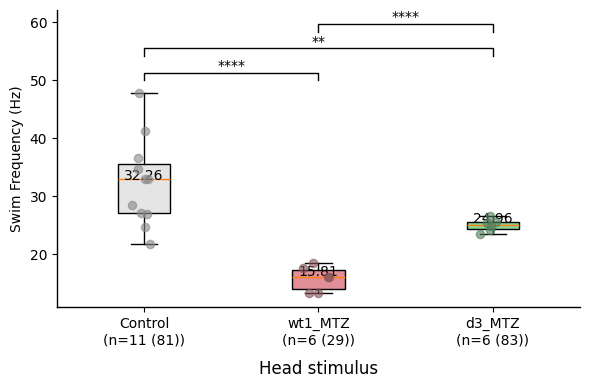

KeyboardInterrupt: Interrupted by user

In [58]:
# Single  Plot
ycol = "Freq. half beats"
df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

df_plot = freq_dist_single(folder=r'\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Plot',
               ycol=ycol,
               Ylabel="Swim Frequency (Hz)",
               df_swim_clean=df_swim_clean,
               df_fish_clean=df_fish_clean)

In [1]:
df.groupby(["Stimulus", "Group"])["UniqueID"].nunique()

NameError: name 'df' is not defined

In [203]:
folder = r'U:\YuanqiHua\High speed\Final analysis\test'

In [14]:
df.columns

Index(['Larva ID', 'Genotype', 'Swim_ID', 'Peak_sequence', 'Peak_deflection',
       'Movement duration', 'Nr. half beats', 'Freq. half beats',
       'Alternation', 'Max. deflection', 'Frame at max deflection',
       'Mean deflection during half beats',
       'Longest tail trajectory among half beats',
       'Cumulative tail trajectory', 'Max. curvature',
       'Frame at max curvature',
       'Tail segment with the max. angle at max. curvature', 'Mean curvature',
       'Mean curvature during beats', 'Turning bias to R/L',
       'Laterality_Index', 'HB10_duration', 'HB10_freq', 'HB10_interval_mean',
       'HB10_interval_cv', 'HB10_alt', 'HB10_amp_mean', 'HB10_amp_max',
       'HB10s_duration', 'HB10s_freq', 'HB10s_interval_mean',
       'HB10s_interval_cv', 'HB10s_alt', 'HB10s_amp_mean', 'HB10s_amp_max',
       'Swimming duration', 'Nr of half beats during swimming',
       'Freq. half beating during swimming', 'Max. deflection during swimming',
       'Frame at max deflection 


Now processing: Freq. half beats

Please enter save folder for Freq. half beats:
Swim-level rows after cleaning: (834, 55)
Fish-level rows after cleaning: (97, 4)

Fish counts (UniqueID) per Stimulus × Group:
Group     Control  d3_MTZ  wt1_MTZ
Stimulus                          
Head           11       7        6
OMR             9      14        7
Tail           10      10       23


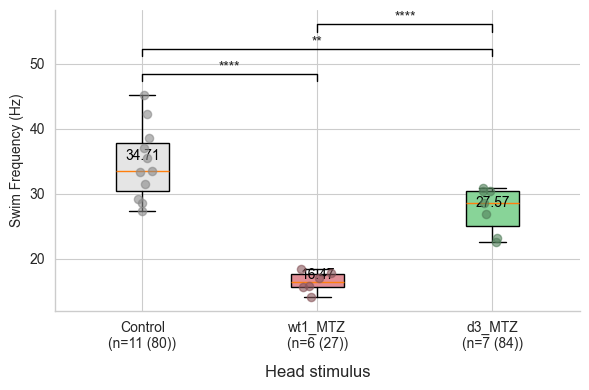

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\freq\Freq._half_beats_Head.png


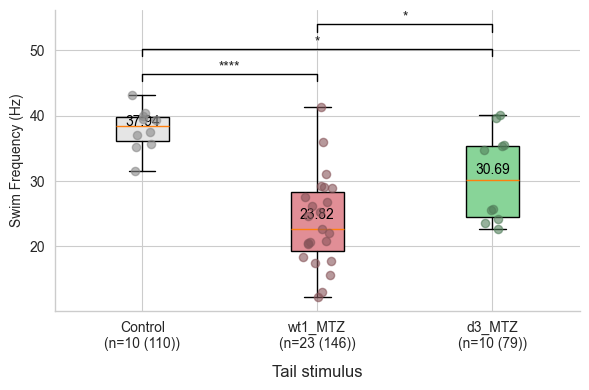

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\freq\Freq._half_beats_Tail.png


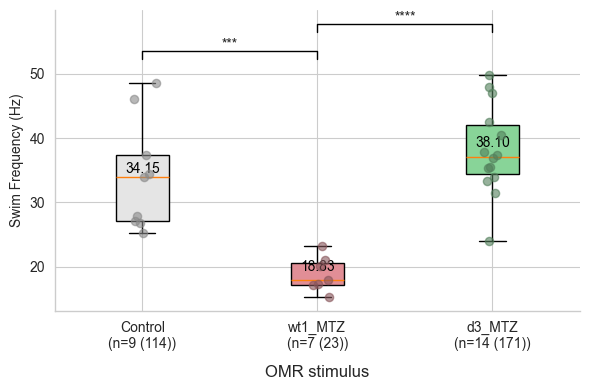

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\freq\Freq._half_beats_OMR.png
           Variable Stimulus   Test    F_value       p_ANOVA   Group1  \
0  Freq. half beats     Head  ANOVA  33.253541  3.103480e-07  Control   
1  Freq. half beats     Head  ANOVA  33.253541  3.103480e-07  Control   
2  Freq. half beats     Head  ANOVA  33.253541  3.103480e-07  wt1_MTZ   
3  Freq. half beats     Tail  ANOVA  17.733124  3.062983e-06  Control   
4  Freq. half beats     Tail  ANOVA  17.733124  3.062983e-06  Control   
5  Freq. half beats     Tail  ANOVA  17.733124  3.062983e-06  wt1_MTZ   
6  Freq. half beats      OMR  ANOVA  18.984605  7.109816e-06  Control   
7  Freq. half beats      OMR  ANOVA  18.984605  7.109816e-06  Control   
8  Freq. half beats      OMR  ANOVA  18.984605  7.109816e-06  wt1_MTZ   

    Group2  n1  n2   t_value         p_raw        p_holm  Significant  
0  wt1_MTZ  11   6  9.930355  2.620802e-07  7.862406e-07         True  
1   d3_MTZ  11

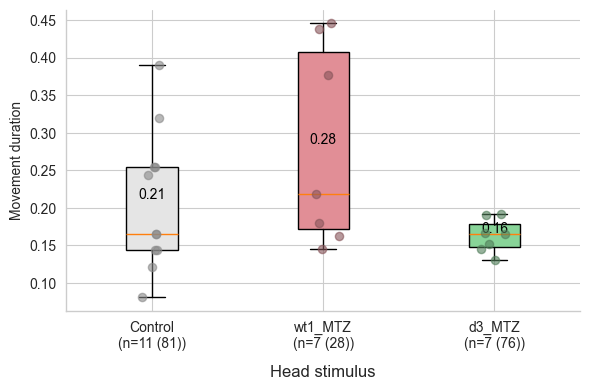

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\duration\Movement_duration_Head.png


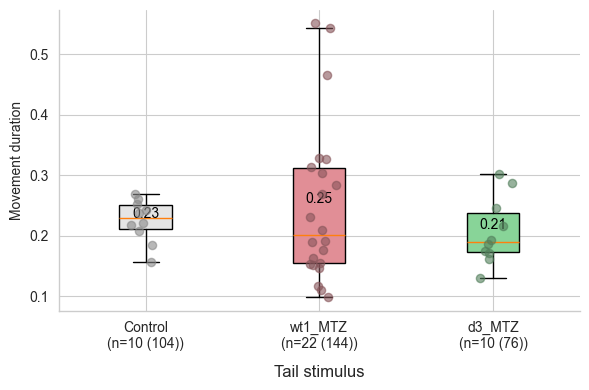

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\duration\Movement_duration_Tail.png


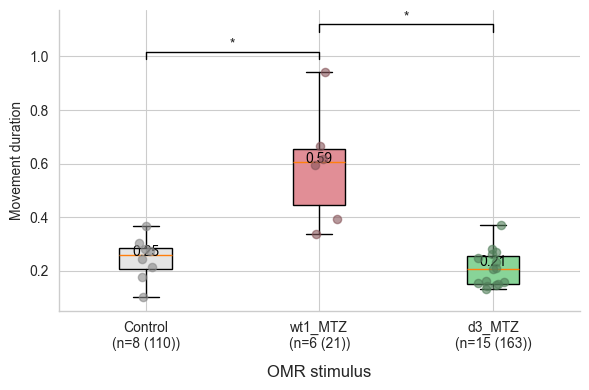

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\duration\Movement_duration_OMR.png
            Variable Stimulus   Test    F_value       p_ANOVA   Group1  \
0  Movement duration     Head  ANOVA   2.787248  8.338078e-02  Control   
1  Movement duration     Head  ANOVA   2.787248  8.338078e-02  Control   
2  Movement duration     Head  ANOVA   2.787248  8.338078e-02  wt1_MTZ   
3  Movement duration     Tail  ANOVA   0.629396  5.382391e-01  Control   
4  Movement duration     Tail  ANOVA   0.629396  5.382391e-01  Control   
5  Movement duration     Tail  ANOVA   0.629396  5.382391e-01  wt1_MTZ   
6  Movement duration      OMR  ANOVA  24.994022  8.809781e-07  Control   
7  Movement duration      OMR  ANOVA  24.994022  8.809781e-07  Control   
8  Movement duration      OMR  ANOVA  24.994022  8.809781e-07  wt1_MTZ   

    Group2  n1  n2   t_value     p_raw    p_holm  Significant  
0  wt1_MTZ  11   7 -1.268441  0.234224  0.310485        False  
1   d3_MTZ  11 

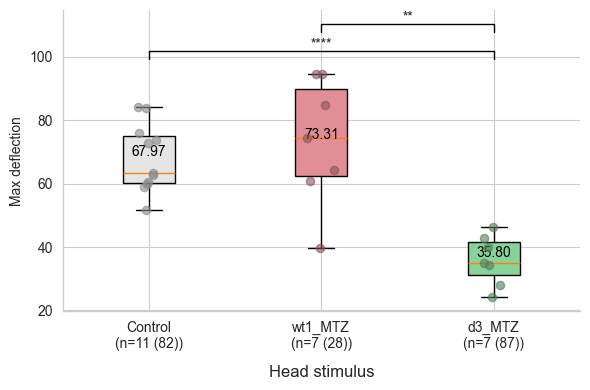

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\deflection\Max._deflection_Head.png


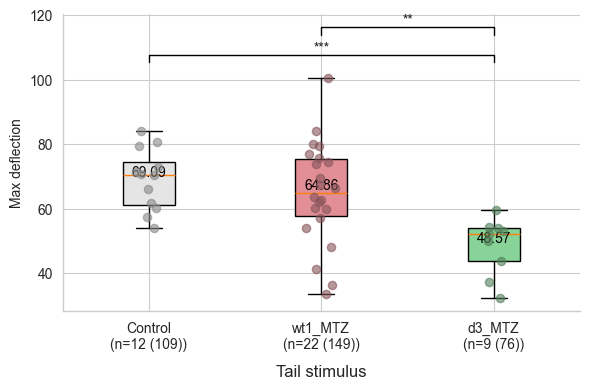

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\deflection\Max._deflection_Tail.png


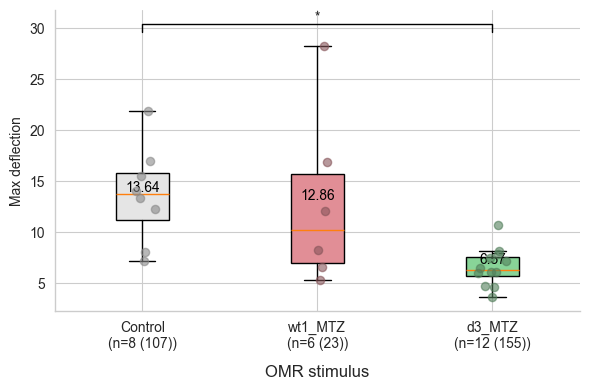

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\deflection\Max._deflection_OMR.png
          Variable Stimulus   Test    F_value   p_ANOVA   Group1   Group2  n1  \
0  Max. deflection     Head  ANOVA  16.801888  0.000037  Control  wt1_MTZ  11   
1  Max. deflection     Head  ANOVA  16.801888  0.000037  Control   d3_MTZ  11   
2  Max. deflection     Head  ANOVA  16.801888  0.000037  wt1_MTZ   d3_MTZ   7   
3  Max. deflection     Tail  ANOVA   6.787009  0.002898  Control  wt1_MTZ  12   
4  Max. deflection     Tail  ANOVA   6.787009  0.002898  Control   d3_MTZ  12   
5  Max. deflection     Tail  ANOVA   6.787009  0.002898  wt1_MTZ   d3_MTZ  22   
6  Max. deflection      OMR  ANOVA   6.014768  0.007923  Control  wt1_MTZ   8   
7  Max. deflection      OMR  ANOVA   6.014768  0.007923  Control   d3_MTZ   8   
8  Max. deflection      OMR  ANOVA   6.014768  0.007923  wt1_MTZ   d3_MTZ   6   

   n2   t_value     p_raw    p_holm  Significant  
0   7 -0.648790  0.534

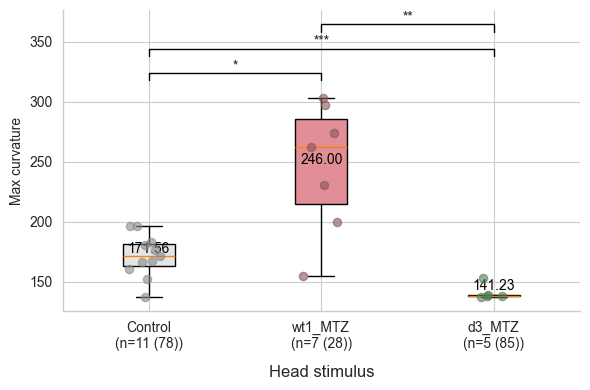

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\curvature\Max._curvature_Head.png


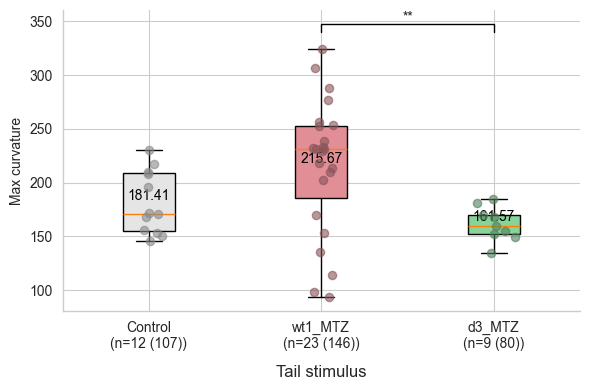

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\curvature\Max._curvature_Tail.png


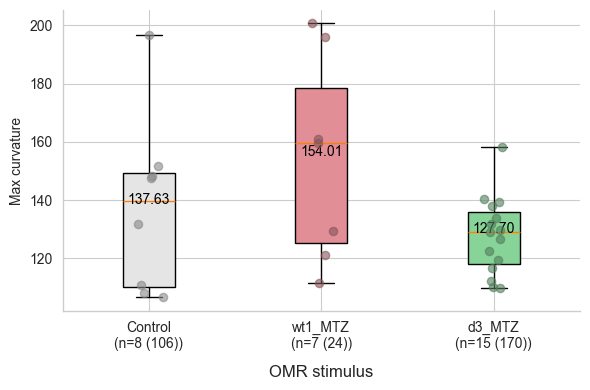

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\curvature\Max._curvature_OMR.png
         Variable Stimulus   Test    F_value   p_ANOVA   Group1   Group2  n1  \
0  Max. curvature     Head  ANOVA  17.883151  0.000035  Control  wt1_MTZ  11   
1  Max. curvature     Head  ANOVA  17.883151  0.000035  Control   d3_MTZ  11   
2  Max. curvature     Head  ANOVA  17.883151  0.000035  wt1_MTZ   d3_MTZ   7   
3  Max. curvature     Tail  ANOVA   4.609495  0.015641  Control  wt1_MTZ  12   
4  Max. curvature     Tail  ANOVA   4.609495  0.015641  Control   d3_MTZ  12   
5  Max. curvature     Tail  ANOVA   4.609495  0.015641  wt1_MTZ   d3_MTZ  23   
6  Max. curvature      OMR  ANOVA   2.708530  0.084716  Control  wt1_MTZ   8   
7  Max. curvature      OMR  ANOVA   2.708530  0.084716  Control   d3_MTZ   8   
8  Max. curvature      OMR  ANOVA   2.708530  0.084716  wt1_MTZ   d3_MTZ   7   

   n2   t_value     p_raw    p_holm  Significant  
0   7 -3.520773  0.010079  0.01007

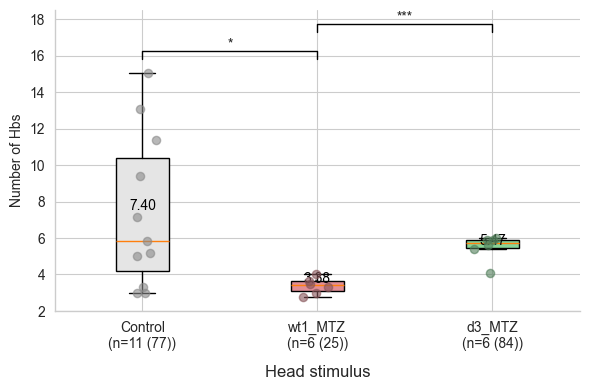

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\Hbs number\Nr._half_beats_Head.png


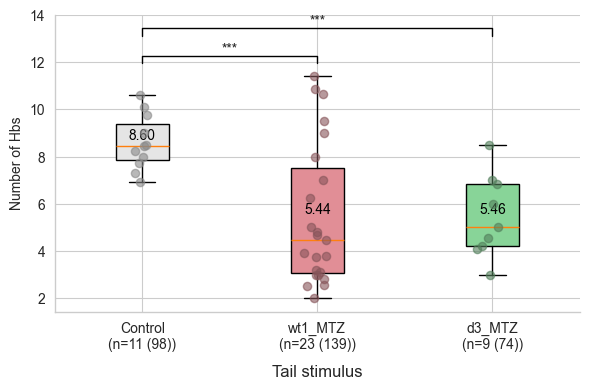

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\Hbs number\Nr._half_beats_Tail.png


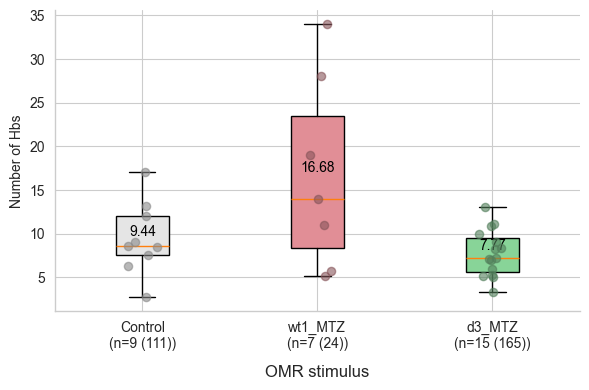

Saved to: U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group\Hbs number\Nr._half_beats_OMR.png
         Variable Stimulus   Test   F_value   p_ANOVA   Group1   Group2  n1  \
0  Nr. half beats     Head  ANOVA  3.499831  0.049741  Control  wt1_MTZ  11   
1  Nr. half beats     Head  ANOVA  3.499831  0.049741  Control   d3_MTZ  11   
2  Nr. half beats     Head  ANOVA  3.499831  0.049741  wt1_MTZ   d3_MTZ   6   
3  Nr. half beats     Tail  ANOVA  6.858082  0.002749  Control  wt1_MTZ  11   
4  Nr. half beats     Tail  ANOVA  6.858082  0.002749  Control   d3_MTZ  11   
5  Nr. half beats     Tail  ANOVA  6.858082  0.002749  wt1_MTZ   d3_MTZ  23   
6  Nr. half beats      OMR  ANOVA  5.623131  0.008852  Control  wt1_MTZ   9   
7  Nr. half beats      OMR  ANOVA  5.623131  0.008852  Control   d3_MTZ   9   
8  Nr. half beats      OMR  ANOVA  5.623131  0.008852  wt1_MTZ   d3_MTZ   7   

   n2   t_value     p_raw    p_holm  Significant  
0   6  3.119670  0.010383  0.020766        

In [16]:
# multiplot

dfs = []
base_folder = r"U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\within group"

for ycol, ylabel in [
    ("Freq. half beats", "Swim Frequency (Hz)"),
    ("HB10_duration", "Movement duration"),
    ("Max. deflection", "Max deflection"),
    ("Max. curvature", "Max curvature"),
    ("HB10_freq", "Number of Hbs")
]:
    print("\n==============================")
    print("Now processing:", ycol)
    print("==============================")

        # ========= 弹窗选择保存 folder =========
    print(f"\nPlease enter save folder for {ycol}:")
    folder_name = input("Folder name: ").strip()

    save_folder = os.path.join(base_folder, folder_name)

    os.makedirs(save_folder, exist_ok=True)

    # Clean data
    df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)
    print("Swim-level rows after cleaning:", df_swim_clean.shape)
    print("Fish-level rows after cleaning:", df_fish_clean.shape)

    print("\nFish counts (UniqueID) per Stimulus × Group:")
    print(
        df_fish_clean
        .groupby(["Stimulus","Group"])["UniqueID"]
        .nunique()
        .unstack(fill_value=0)
    )

    # Plot
    df_plot = within_group(
        folder=save_folder,
        ycol=ycol,
        Ylabel=ylabel,
        df_swim_clean=df_swim_clean,
        df_fish_clean=df_fish_clean
    )

    dfs.append(df_plot)

df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv(os.path.join(base_folder, "ALL_ANOVA_Holm_stats.csv"), index=False)

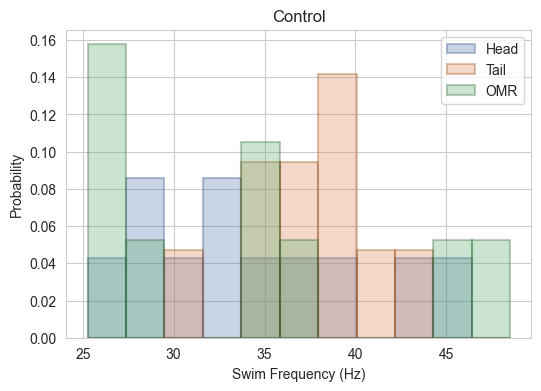

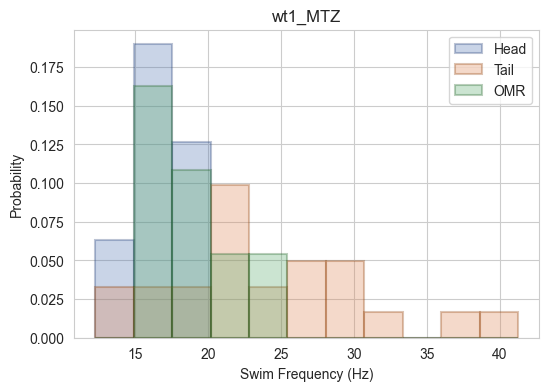

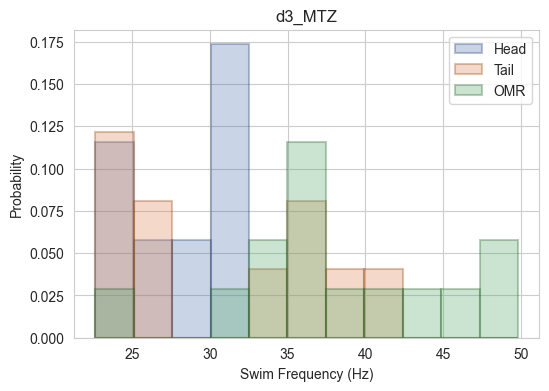

In [5]:


ycol = "Freq. half beats"
df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

freq_dist_all2(
    folder=r"U:\YuanqiHua\High speed\Final analysis\test\Plot\ALL SWIM\Freq distribution",
    ycol="Freq. half beats",
    savename = "Freq_distribution",
    df_fish_clean=df_fish_clean
)

# 柱子的位置反映数据分布在哪个频率区间；
# 柱子的高度（在统一 bins 下）反映该组在该区间的相对概率，峰越高通常表示该分布越集中。

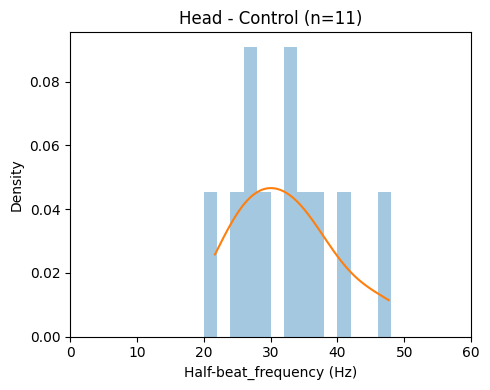

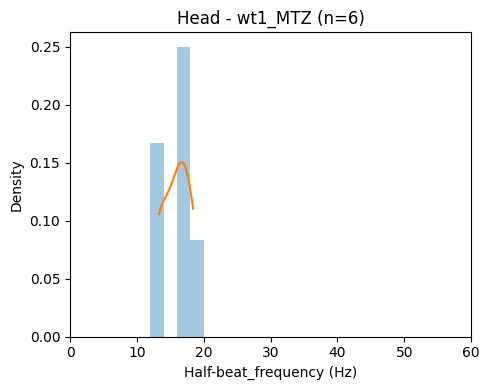

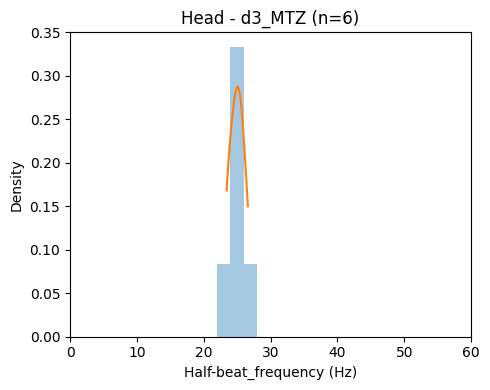

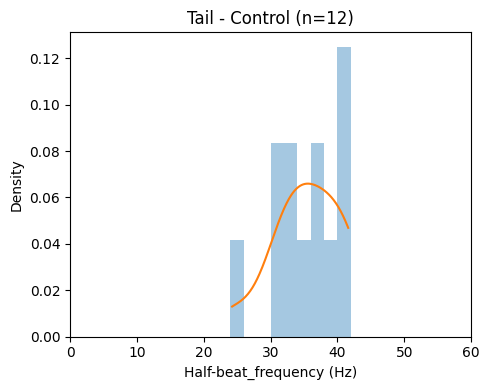

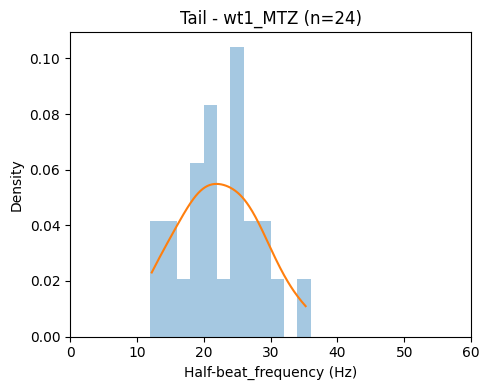

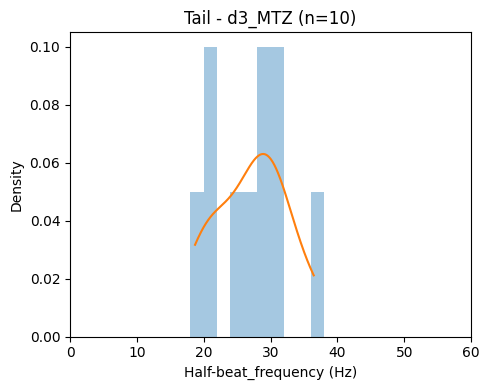

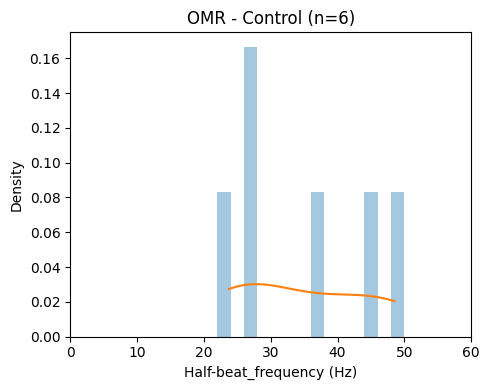

C:\Users\huayuanqi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


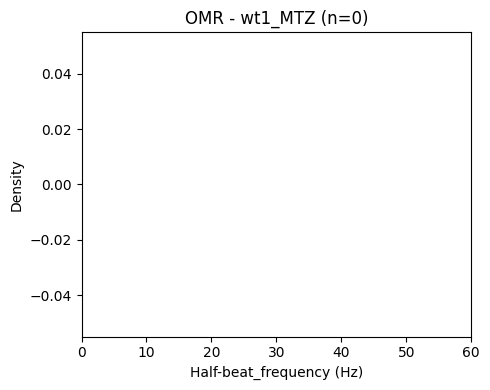

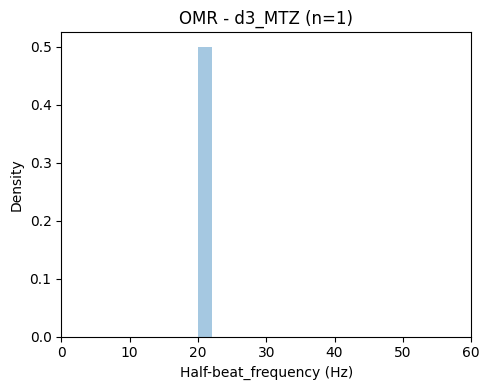

In [71]:
ycol = "Freq. half beats"
df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

Freq_dist_sigle(folder=r"\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Plot",
           ycol="Freq. half beats",
           savename = "Freq_distribution",
           df_fish_clean=df_fish_clean
           )

# 前10HB 的细节

In [8]:
df2 = final_df

In [148]:
ids = (
    df2.loc[
        (df["Group"] == "d3_MTZ") &
        (df["Stimulus"] == "Head"),
        "UniqueID"
    ]
    .unique()
)

ids

array([11, 12, 13, 14, 15, 16, 17])

In [149]:
# 清空Nah值并合并
def make_clean_long(df, ycol):
    # groups = ["Control","wt1_MTZ","d3_MTZ"]
    # df = df[df["Group"].isin(groups)].copy() # only for groups over these 3

    df = df.dropna(subset=[ycol])

    df_fish = (
        df.groupby(["Group", "UniqueID" , "Stimulus", "HB_index"], as_index=False)
          .agg({ycol: "mean"})
    )

    return df_fish

In [150]:
df_fish_clean = make_clean_long(df, "Inst_freq_Hz")
df_fish_clean.head(10)

,Group,UniqueID,Stimulus,HB_index,Inst_freq_Hz
0,Control,1,Tail,1,44.328152
1,Control,1,Tail,2,54.162274
2,Control,1,Tail,3,53.550517
3,Control,1,Tail,4,53.773788
4,Control,1,Tail,5,49.710927
5,Control,1,Tail,6,52.780067
6,Control,1,Tail,7,49.454034
7,Control,1,Tail,8,49.152302
8,Control,1,Tail,9,46.458518
9,Control,2,Tail,1,52.631579


In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
from matplotlib.lines import Line2D

colors = {"Control": "#999999", "wt1_MTZ": "#E18E96", "d3_MTZ": "#88D498"}
groups = ["Control", "wt1_MTZ", "d3_MTZ"]
# pairs = [("Control", "wt1_MTZ"), ("Control", "d3_MTZ"), ("wt1_MTZ", "d3_MTZ")] only for ANOVA

def star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def holm_adjust(pvals):
    """
    Holm-Bonferroni adjustment.
    input: list of p-values
    output: list of adjusted p-values in original order
    """
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    for k, idx in enumerate(order):
        adj[idx] = min((m - k) * pvals[idx], 1.0)
    # enforce monotonicity (optional but nice)
    # sort adj by p order and cummax then map back
    adj_sorted = adj[order]
    adj_sorted = np.maximum.accumulate(adj_sorted)
    adj[order] = adj_sorted
    return adj.tolist()

def plot_instfreq_anova_pairs(df_fish_clean, Ylabel, stim="Head", y="Inst_freq_Hz", err="sem"):

    sub = df_fish_clean[df_fish_clean["Stimulus"] == stim].copy() # 只保留 Stimulus == "Head"
    sub = sub.dropna(subset=[y, "HB_index", "Group"]) # 丢掉 y 或 HB_index 或 Group 缺失的行

    hbs = sorted(sub["HB_index"].unique())
    # 如果你的 HB_index 是 1..9，这里会自动是 1..9；否则按实际来
    y_min = float(sub[y].min())
    y_max = float(sub[y].max())
    y_range = max(y_max - y_min, 1e-6)

    fig, ax = plt.subplots(figsize=(8.5, 4.2))

    # 灰白交替背景
    for i, hb in enumerate(hbs, start=1):
        if i % 2 == 0:
            ax.axvspan(hb - 0.5, hb + 0.5, color="0.92", zorder=0)

    offsets = {"Control": -0.22, "wt1_MTZ": 0.0, "d3_MTZ": 0.22}

    # 画点 + mean±SEM/SD
    for g in groups:
        dg = sub[sub["Group"] == g]
        if dg.empty:
            continue

        for hb in hbs:
            vals = dg[dg["HB_index"] == hb][y].to_numpy()
            if len(vals) == 0:
                continue

            x0 = hb + offsets[g]

            # scatter (每条鱼一个点)
            jitter = np.random.uniform(-0.03, 0.03, size=len(vals))
            ax.scatter(np.full(len(vals), x0) + jitter, vals,
                       s=26, alpha=0.65, color=colors[g], edgecolor="none", zorder=2)

            # mean + errorbar
            m = float(np.mean(vals))
            if err == "sd":
                e = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            else:  # sem
                e = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0

            ax.errorbar([x0], [m], yerr=[e],
                        fmt="o", markersize=6,
                        color=colors[g], capsize=3, linewidth=1.6, zorder=3)

 # =========================
    # ✅ 统计：只做两组比较（Control vs wt1, Control vs d3）
    # ✅ Holm 校正在“所有HB的两类比较”上一起做
    # =========================
    control_pairs = [("Control", "wt1_MTZ"), ("Control", "d3_MTZ")]

    raw_rows = []
    raw_pvals = []

    for hb in hbs:
        for (g1, g2) in control_pairs:
            v1 = sub[(sub["Group"] == g1) & (sub["HB_index"] == hb)][y].to_numpy()
            v2 = sub[(sub["Group"] == g2) & (sub["HB_index"] == hb)][y].to_numpy()

            # 样本量不够就不检验
            if len(v1) < 2 or len(v2) < 2:
                p = np.nan
            else:
                p = ttest_ind(v1, v2, equal_var=False).pvalue  # Welch t-test ,→ 不要求两组方差相等，更适合你说的“Control 分布很宽”。

            raw_rows.append({"HB_index": hb, "g1": g1, "g2": g2, "n1": len(v1), "n2": len(v2), "p": p})
            raw_pvals.append(p)

    # Holm 校正：对所有有效p一起校正
    stats_table = pd.DataFrame(raw_rows)
    stats_table["p_holm"] = np.nan

    valid_mask = stats_table["p"].notna()
    valid_p = stats_table.loc[valid_mask, "p"].to_list()
    if len(valid_p) > 0:
        adj = holm_adjust(valid_p)
        stats_table.loc[valid_mask, "p_holm"] = adj

    stats_table["star"] = stats_table["p_holm"].apply(lambda x: star(x) if pd.notna(x) else "na")

    # 标星位置：两行（因为只有两种比较）
    for hb in hbs:
        base = float(sub[sub["HB_index"] == hb][y].max())
        step = 0.06 * y_range

        tab_hb = stats_table[stats_table["HB_index"] == hb]

        for k, (g1, g2) in enumerate(control_pairs):
            row = tab_hb[(tab_hb["g1"] == g1) & (tab_hb["g2"] == g2)]
            if row.empty:
                continue
            s = row["star"].iloc[0]
            if s in ["ns", "na"]:
                continue

            # k=0 放第一行，k=1 放第二行
            ax.text(hb, base + (k + 1) * step, s,
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color="black")


 #  # 每个HB：ANOVA + 两两比较（Holm校正）
 #  for hb in hbs:
 #      vals_by_group = []
 #      for g in groups:
 #          v = sub[(sub["Group"] == g) & (sub["HB_index"] == hb)][y].to_numpy()
 #          vals_by_group.append(v)

 #      # ANOVA 要求每组至少2个样本比较稳（也可放宽到>=1但意义弱）
 #      if any(len(v) < 2 for v in vals_by_group):
 #          continue

 #      # one-way ANOVA
 #      p_anova = f_oneway(*vals_by_group).pvalue

 #      # 只有 ANOVA 显著才做 posthoc（你也可以改成永远做）
 #      if p_anova >= 0.05:
 #          continue

 #      # pairwise Welch t-tests
 #      pvals = []
 #      for (g1, g2) in pairs:
 #          v1 = sub[(sub["Group"] == g1) & (sub["HB_index"] == hb)][y].to_numpy()
 #          v2 = sub[(sub["Group"] == g2) & (sub["HB_index"] == hb)][y].to_numpy()
 #          p = ttest_ind(v1, v2, equal_var=False).pvalue
 #          pvals.append(p)

 #      pvals_adj = holm_adjust(pvals)

 #      # 星号位置：堆叠三行
 #      base = float(sub[sub["HB_index"] == hb][y].max())
 #      step = 0.06 * y_range

 #      for k, ((g1, g2), p_adj) in enumerate(zip(pairs, pvals_adj)):
 #          s = star(p_adj)
 #          if s == "ns":
 #              continue
 #          ax.text(hb, base + (k + 1) * step, s, ha="center", va="bottom",
 #                  fontsize=11, fontweight="bold", color="black")

    # 标题坐标轴
    ax.set_title(f"{stim} stimulus")
    ax.set_xlabel("HB index")
    Ylabel = Ylabel
    ax.set_ylabel(f"{Ylabel}")
    ax.set_xticks(hbs)

    # ✅ 手动 legend（永远有）
    handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[g],
               markeredgecolor='none', markersize=7, label=g)
        for g in groups
    ]
    ax.legend(handles=handles,
              frameon=False,
              loc="center left",
              bbox_to_anchor=(1.02, 0.5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    filename = f"Frequency for each hb(10hb){stim}.png"
    full_path = os.path.join(folder, filename)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")

    plt.show()

    # ✅ 返回统计表（你要单独查看数值）
    return stats_table



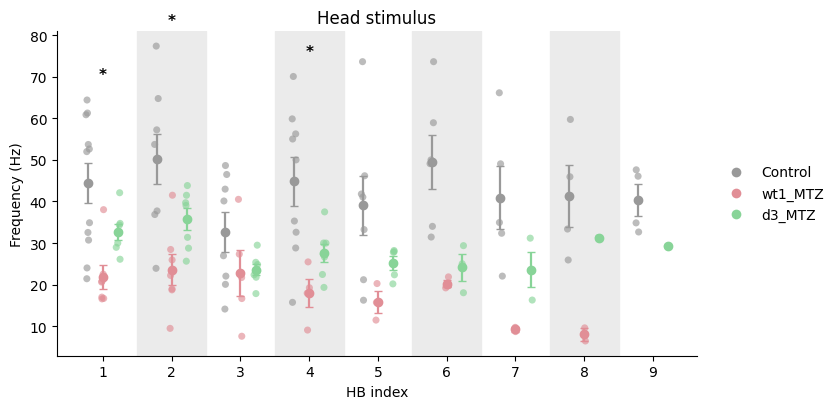

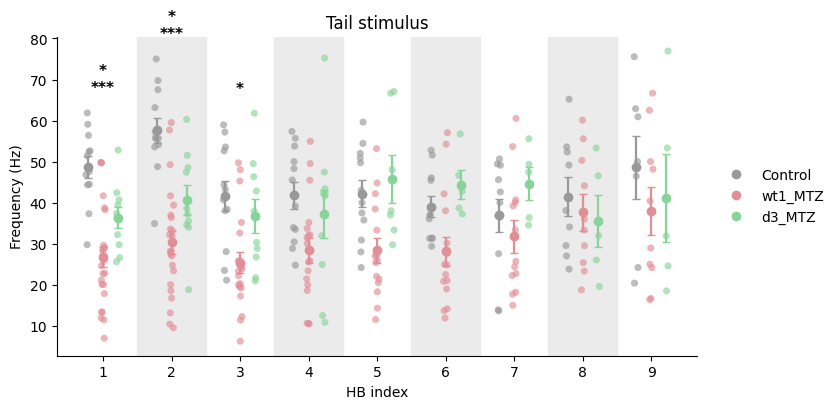

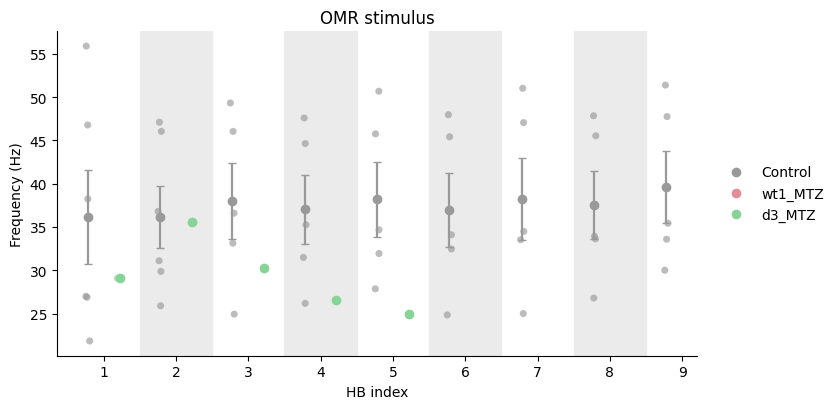

In [190]:
# 用法1
df_fish_clean = df_fish_clean[df_fish_clean["Inst_freq_Hz"] < 80]

tab_head = plot_instfreq_anova_pairs(df_fish_clean, stim="Head", y="Inst_freq_Hz", Ylabel="Frequency (Hz)")
tab_tail = plot_instfreq_anova_pairs(df_fish_clean, stim="Tail", y="Inst_freq_Hz", Ylabel="Frequency (Hz)")
tab_omr  = plot_instfreq_anova_pairs(df_fish_clean, stim="OMR",  y="Inst_freq_Hz", Ylabel="Frequency (Hz)")

# For each HB_index, we compared Control with wt1_MTZ and d3_MTZ using Welch’s t-test. P values were corrected for multiple comparisons across HB indices using Holm adjustment.

#

In [194]:
tab_head
tab_head.to_csv(os.path.join(folder, "stats_Control_vs_treat_Head.csv"), index=False)
tab_tail.to_csv(os.path.join(folder, "stats_Control_vs_treat_Tail.csv"), index=False)
tab_omr.to_csv(os.path.join(folder, "stats_Control_vs_treat_OMR.csv"), index=False)


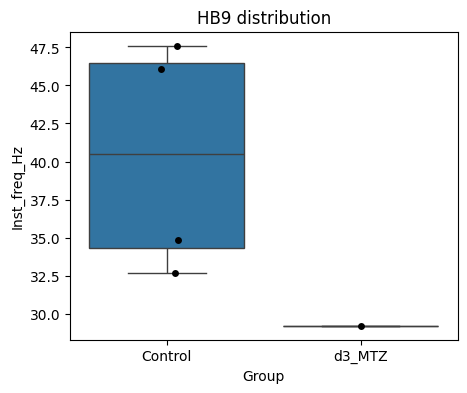

In [168]:
# 看看 Control 某个 HB（比如 HB2）是不是被 1–2 条鱼拉宽。
import seaborn as sns
import matplotlib.pyplot as plt

hb =
sub_hb = df_fish_clean[
    (df_fish_clean["Stimulus"]=="Head") &
    (df_fish_clean["HB_index"]==hb)
]

plt.figure(figsize=(5,4))
sns.boxplot(data=sub_hb, x="Group", y="Inst_freq_Hz")
sns.stripplot(data=sub_hb, x="Group", y="Inst_freq_Hz", color="black", size=5)
plt.title(f"HB{hb} distribution")
plt.show()

In [174]:
sub_hb.groupby(["HB_index","Group"])["UniqueID"].nunique()

HB_index  Group  
9         Control    4
          d3_MTZ     1
Name: UniqueID, dtype: int64

In [199]:
# p value
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, ttest_ind

groups = ["Control", "wt1_MTZ", "d3_MTZ"]
pairs = [("Control","wt1_MTZ"), ("Control","d3_MTZ"), ("wt1_MTZ","d3_MTZ")]

def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    for k, idx in enumerate(order):
        adj[idx] = min((m - k) * pvals[idx], 1.0)
    # monotonicity
    adj_sorted = adj[order]
    adj_sorted = np.maximum.accumulate(adj_sorted)
    adj[order] = adj_sorted
    return adj.tolist()

def fdr_bh(pvals):
    """Benjamini-Hochberg FDR"""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty(m, dtype=float)
    out[order] = q
    return out.tolist()

def hbwise_anova_posthoc(df_fish_clean, stim="Head", y="Inst_freq_Hz"):
    sub = df_fish_clean[df_fish_clean["Stimulus"] == stim].copy()
    sub = sub.dropna(subset=[y, "HB_index", "Group"])

    hbs = sorted(sub["HB_index"].unique())

    results = []
    anova_pvals = []

    # 1) 每个HB：ANOVA
    for hb in hbs:
        vals = []
        ns = []
        for g in groups:
            v = sub[(sub["Group"] == g) & (sub["HB_index"] == hb)][y].to_numpy()
            vals.append(v)
            ns.append(len(v))

        # 要求每组至少2个才做ANOVA比较稳
        if any(n < 2 for n in ns):
            anova_p = np.nan
        else:
            anova_p = f_oneway(*vals).pvalue

        anova_pvals.append(anova_p)
        results.append({"Stimulus": stim, "HB_index": hb, "ANOVA_p": anova_p})

    # 2) 对 9个HB 的 ANOVA p 做 FDR（可选但推荐）
    valid_idx = [i for i,p in enumerate(anova_pvals) if np.isfinite(p)]
    anova_q = [np.nan]*len(anova_pvals)
    if valid_idx:
        qvals = fdr_bh([anova_pvals[i] for i in valid_idx])
        for i, q in zip(valid_idx, qvals):
            anova_q[i] = q

    # 3) 每个HB：pairwise（并对该HB的三次比较做 Holm 校正）
    for i, hb in enumerate(hbs):
        row = results[i]
        row["ANOVA_q"] = anova_q[i]

        # 只有 ANOVA（或ANOVA_q）显著才做posthoc（你也可以改成永远做）
        if not np.isfinite(row["ANOVA_p"]) or row["ANOVA_p"] >= 0.05:
            for (g1,g2) in pairs:
                row[f"{g1}_vs_{g2}_p"] = np.nan
                row[f"{g1}_vs_{g2}_p_holm"] = np.nan
            continue

        pvals = []
        raw = {}
        for (g1,g2) in pairs:
            v1 = sub[(sub["Group"] == g1) & (sub["HB_index"] == hb)][y].to_numpy()
            v2 = sub[(sub["Group"] == g2) & (sub["HB_index"] == hb)][y].to_numpy()
            p = ttest_ind(v1, v2, equal_var=False).pvalue
            raw[(g1,g2)] = p
            pvals.append(p)

        adj = holm_adjust(pvals)
        for (g1,g2), p, ph in zip(pairs, pvals, adj):
            row[f"{g1}_vs_{g2}_p"] = p
            row[f"{g1}_vs_{g2}_p_holm"] = ph

    return pd.DataFrame(results)

# 用法：
res_head = hbwise_anova_posthoc(df, stim="Head",y = "Interval_s")
res_tail = hbwise_anova_posthoc(df, stim="Tail",y = "Interval_s")
res_head.to_csv(os.path.join(folder, "Duration_Head.csv"), index=False)
res_tail.to_csv(os.path.join(folder, "Duration_Tail.csv"), index=False)
res_head.head(20)

## explainaion
# p < 0.05 → 三组中至少有一组不同, 如果 ANOVA_q < 0.05 → 在多HB校正后仍显著 → 更稳健 这一步只是告诉你：“三组整体有差异”, 但不知道谁和谁不同。
#

,Stimulus,HB_index,ANOVA_p,ANOVA_q,Control_vs_wt1_MTZ_p,Control_vs_wt1_MTZ_p_holm,Control_vs_d3_MTZ_p,Control_vs_d3_MTZ_p_holm,wt1_MTZ_vs_d3_MTZ_p,wt1_MTZ_vs_d3_MTZ_p_holm
0,Head,1,0.000214,0.000321,0.005972,0.011945,1.097521e-03,3.292563e-03,0.120139,0.120139
1,Head,2,0.004719,0.005309,0.030404,0.076138,2.537933e-02,7.613799e-02,0.166574,0.166574
2,Head,3,0.000340,0.000437,0.035147,0.070295,4.643608e-04,1.393082e-03,0.204011,0.204011
3,Head,4,0.000189,0.000321,0.059754,0.119509,3.457935e-07,1.037381e-06,0.803865,0.803865
4,Head,5,0.000023,0.000068,0.057081,0.114163,2.834413e-08,8.503238e-08,0.279051,0.279051
5,Head,6,0.000107,0.000241,0.080390,0.160779,5.368234e-08,1.610470e-07,0.395756,0.395756
6,Head,7,0.000001,0.000012,0.061775,0.123551,3.476058e-11,1.042818e-10,0.692693,0.692693
7,Head,8,0.000005,0.000024,0.029718,0.059436,2.187172e-04,6.561515e-04,0.882250,0.882250
8,Head,9,0.006251,0.006251,0.794465,0.794465,5.122333e-03,1.536700e-02,0.168766,0.337533


# heatmap plot

Saved: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Freqmap_heatmap\260114  wt1 MTZ control_1000fps_freqmap_long_heatmap.png


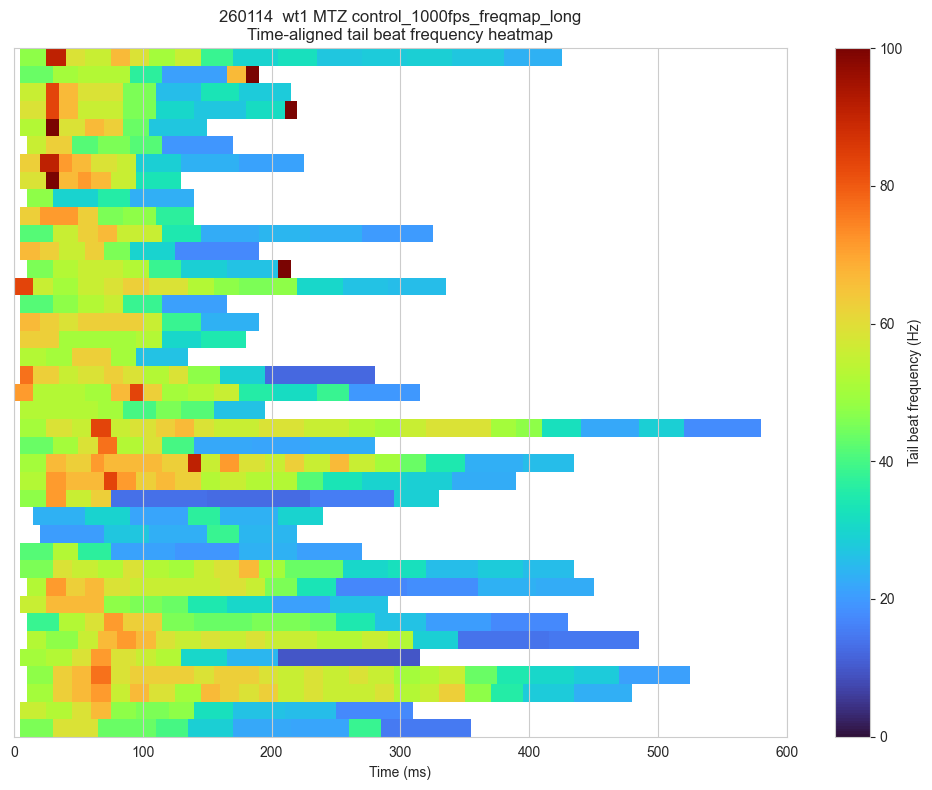

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# PARAMETERS
# =========================================================
csv_path = r'U:\YuanqiHua\High speed\Final analysis\Freqmap_long\test\260114  wt1 MTZ control_1000fps_freqmap_long.csv'
save_folder = r'\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Freqmap_heatmap'

# 统一时间轴设置
max_time_ms = 600        # X轴到多少 ms
bin_ms = 5               # 时间分箱宽度，5 ms 比较常用；也可改成 2 / 10

# 颜色范围
vmin = 0
vmax = 100               # 按你的鱼速度调，比如 80 / 100 / 120

# 排序方式
# "none"          -> 按原始顺序
# "duration"      -> 按每个 swim 最后结束时间排序
# "max_freq"      -> 按最大频率排序
# "mean_freq"     -> 按平均频率排序
sort_mode = "duration_asc"
cmap = "turbo"

show_plot = True
save_plot = True

os.makedirs(save_folder, exist_ok=True)


# =========================================================
# HELPERS
# =========================================================
def build_heatmap_matrix(df, max_time_ms=600, bin_ms=5, sort_mode="none"):
    """
    输入:
        df: freqmap_long dataframe
    输出:
        matrix: (n_swims, n_bins)
        swim_labels: 每一行对应的 swim 标签
        time_edges: 时间边界
        time_centers: 时间中心
    """

    # 给每个 swim 一个唯一标签
    # 这样不同 Larva 的同一个 Swim_ID 不会撞名
    df = df.copy()
    df["swim_key"] = (
        df["Larva_ID"].astype(str) + "|" +
        df["Genotype"].astype(str) + "|" +
        df["Swim_ID"].astype(str)
    )

    swim_keys = list(df["swim_key"].drop_duplicates())

    # 时间分箱
    n_bins = int(max_time_ms / bin_ms)
    time_edges = np.arange(0, max_time_ms + bin_ms, bin_ms)
    time_centers = time_edges[:-1] + bin_ms / 2

    # 初始化矩阵
    matrix = np.full((len(swim_keys), n_bins), np.nan, dtype=float)

    # 保存排序指标
    sort_values = []

    for row_idx, swim_key in enumerate(swim_keys):
        sub = df[df["swim_key"] == swim_key].copy()

        # 可选：按 interval 顺序排一下
        if "Interval_index" in sub.columns:
            sub = sub.sort_values("Interval_index")

        # 把每个 interval 填到对应时间段
        for _, r in sub.iterrows():
            start_ms = float(r["Start_ms"])
            end_ms = float(r["End_ms"])
            freq = float(r["Inst_freq_Hz"])

            # 跳过异常值
            if not np.isfinite(start_ms) or not np.isfinite(end_ms) or not np.isfinite(freq):
                continue
            if end_ms <= 0:
                continue
            if start_ms >= max_time_ms:
                continue

            # 截断到显示窗口
            s = max(0.0, start_ms)
            e = min(float(max_time_ms), end_ms)

            if e <= s:
                continue

            # 转成 bin index
            start_bin = int(np.floor(s / bin_ms))
            end_bin = int(np.ceil(e / bin_ms))

            start_bin = max(0, start_bin)
            end_bin = min(n_bins, end_bin)

            matrix[row_idx, start_bin:end_bin] = freq

        # 排序指标
        valid = matrix[row_idx, np.isfinite(matrix[row_idx])]
        if len(valid) == 0:
            duration_val = -np.inf
            max_freq_val = -np.inf
            mean_freq_val = -np.inf
        else:
            duration_val = np.max(sub["End_ms"].to_numpy())
            max_freq_val = np.nanmax(valid)
            mean_freq_val = np.nanmean(valid)

        if sort_mode == "duration":
            sort_values.append(duration_val)
        elif sort_mode == "max_freq":
            sort_values.append(max_freq_val)
        elif sort_mode == "mean_freq":
            sort_values.append(mean_freq_val)
        else:
            sort_values.append(row_idx)

    # 排序
    if sort_mode != "none":
        order = np.argsort(sort_values)[::-1]   # 从大到小
        matrix = matrix[order]
        swim_keys = [swim_keys[i] for i in order]

    return matrix, swim_keys, time_edges, time_centers


def make_swim_labels(swim_keys):
    labels = []
    for k in swim_keys:
        larva, genotype, swim_id = k.split("|", 2)
        labels.append(f"L{larva}_S{swim_id}")
    return labels


# =========================================================
# MAIN
# =========================================================
def main():
    df = pd.read_csv(csv_path)

    required_cols = [
        "Larva_ID", "Genotype", "Swim_ID",
        "Start_ms", "End_ms", "Inst_freq_Hz"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in csv: {missing}")

    matrix, swim_keys, time_edges, time_centers = build_heatmap_matrix(
        df,
        max_time_ms=max_time_ms,
        bin_ms=bin_ms,
        sort_mode=sort_mode
    )

    swim_labels = make_swim_labels(swim_keys)

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        origin="upper",
        extent=[0, max_time_ms, len(swim_keys), 0],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Tail beat frequency (Hz)")

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("")

    # X轴刻度
    ax.set_xticks(np.arange(0, max_time_ms + 1, 100))

    # Y轴如果太多，就不显示每一行标签
    ax.set_yticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)

    basename = os.path.splitext(os.path.basename(csv_path))[0]
    ax.set_title(f"{basename}\nTime-aligned tail beat frequency heatmap")

    plt.tight_layout()

    if save_plot:
        outpath = os.path.join(save_folder, basename + "_heatmap.png")
        plt.savefig(outpath, dpi=200, bbox_inches="tight")
        print("Saved:", outpath)

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


if __name__ == "__main__":
    main()

In [ ]:
# 运动强度类 运动幅度有多大
# Max. deflection
# Longest tail trajectory
# Cumulative tail trajectory
# Max curvature


In [ ]:
# 节律类 运动快慢 / 动力节律
# Nr. half beats
# Freq. half beats

In [ ]:
# 持续时间 运动是否持续
# Movement duration
# Swimming duration

In [ ]:
# 运动对称性 是否有偏侧化（neural asymmetry）
# Turning bias R/L